# Solution 3. A pumping well near a river in uniform background flow
## Exercises 1, 2 & 3 — Solution
##### A.A.Aliyu - 6613535

In [1]:
# import standard packages
import numpy as np
import matplotlib.pyplot as plt

In virtually all aquifers, the natural groundwater flow is towards a stream, river, lake, or ocean. This flow is also called the background flow, as it is present prior to the installation of a well. The background flow may be estimated, e.g., from the heads in two observation wells. For example, the flow in the $x$-direction may be obtained from two observation wells aligned in the $x$-direction as
\begin{equation}
U\approx T\frac{\Delta h}{\Delta x}
\end{equation}
where $\Delta h$ is the head drop between the observation wells and $\Delta x$ is the distance between the two observation wells. 

Here, we are considering a pumping well near a long and straight river running North-South (as in the previous solution), but now with a uniform background flow towards the river (i.e., in the $x$-direction), as shown in the figure.

<img src="wellriveruflow.png" width="350px">

The solution for the head in the aquifer is obtained from the previous solution by adding a uniform flow term in the $x$-direction. The solutions for the head and flow are

\begin{equation}
h = \frac{Q}{4\pi T}\ln\left[\frac{(x-x_w)^2 + (y-y_w)^2}{(x+x_w)^2 + (y-y_w)^2}\right] 
-\frac{U}{T}x + h_0
\end{equation}

\begin{equation}
Q_x = -\frac{Q}{2\pi}\left[\frac{x-x_w}{(x-x_w)^2 + (y-y_w)^2} - 
\frac{x+x_w}{(x+x_w)^2 + (y-y_w)^2} \right] + U
\end{equation}
\begin{equation}
Q_y = -\frac{Q}{2\pi}\left[\frac{y-y_w}{(x-x_w)^2 + (y-y_w)^2} - 
\frac{y-y_w}{(x+x_w)^2 + (y-y_w)^2} \right]
\end{equation}

Consider a well in a uniform background flow near a river. 

In [2]:
# parameters
k = 20 # hydraulic conductivity, m/d
H = 10 # m
xw = -200 # x-location of well, m
yw = 0 # y-location of well, m
Q = 200 # discharge of well, m^3/d
rw = 0.3 # radius of well, m
h0 = 20 # river level, m
n = 0.3 # porosity, -
T = k * H # transmissivity, m^2/d

In [3]:
# parameters uniform background flow
delx = 1000 # distance between observation wells
delh = 2 # head drop between observation wells
U = T * delh / delx
print(f'Uniform flow U = {U:.1f} m^2/d')

Uniform flow U = 0.4 m^2/d


In [4]:
def head(x, y, xw, yw, Q, T, h0, U=0):
    h = Q / (4 * np.pi * T) * np.log(
    ((x - xw) ** 2 + (y - yw) ** 2) /
    ((x + xw) ** 2 + (y - yw) ** 2)) -U * x / T + h0
    return h

def QxQy(x, y, xw, yw, Q, U=0):
    r1sq = (x - xw) ** 2 + (y - yw) ** 2
    r2sq = (x + xw) ** 2 + (y - yw) ** 2
    Qx = -Q / (2 * np.pi) * ((x - xw) / r1sq - (x + xw) / r2sq) + U
    Qy = -Q / (2 * np.pi) * ((y - yw) / r1sq - (y - yw) / r2sq)
    return Qx, Qy

def streamfunction(x, y, xw, yw, Q, U=0):
    # stream function: dpsi/dy = Qx,  dpsi/dx = -Qy
    psi = Q / (2 * np.pi) * (
        np.arctan2(y - yw, x + xw) - np.arctan2(y - yw, x - xw)) + U * y
    return psi

The head is contoured and a streamplot is created. 20 streamlines are started from $x=-600$ m, equally distribute between $y=-300$ and $y=+300$.

In [5]:
xg, yg = np.meshgrid(np.linspace(-600, 0, 100), np.linspace(-300, 300, 100))
h = head(xg, yg, xw, yw, Q, T, h0, U)
print(f'min and max head in window: {h.min():.1f} m, {h.max():.1f} m')
Qx, Qy = QxQy(xg, yg, xw, yw, Q, U)

min and max head in window: 19.6 m, 21.1 m


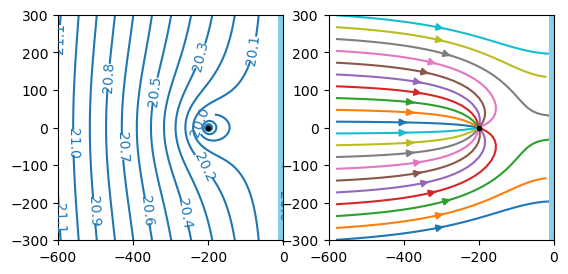

In [6]:
plt.subplot(121, aspect=1)
cs = plt.contour(xg, yg, h, np.arange(19, 22, 0.1), colors='C0')
plt.clabel(cs, fmt='%1.1f')
plt.plot(xw, yw, 'k.')
plt.axvline(0, color='skyblue', lw=8)
#
plt.subplot(122, aspect=1)
xstart = -600 * np.ones(20)
ystart = np.linspace(-300, 300, 20)
for i in range(20):
    plt.streamplot(xg, yg, Qx, Qy, start_points=[(xstart[i], ystart[i])], 
                   integration_direction='forward')
plt.plot(xw, yw, 'k.')
plt.axvline(0, color='skyblue', lw=8);

There appears to be a stagnation point (a point with zero velocity) between the well and the river. This point may be found by setting $Q_x=0$ along the line $y=y_w$ and solving for $x$, which gives the location $x_s$ of the stagnation point:
\begin{equation}
x_s = -\sqrt{x_w^2 + \frac{Qx_w}{\pi U}}
\end{equation}
Two streamlines are started from the stagnation point, one just above the stagnation point and one just below the stagnation point. The streamlines are integrated `backward`, so against the flow. These two streamlines bound the capture zone envelope, the area of the aquifer that is (eventually) captured by the well. Note that far upstream the width of the capture zone envelope is $W=Q/U$.

width of capture zone envelope far upstream: 500.0 m


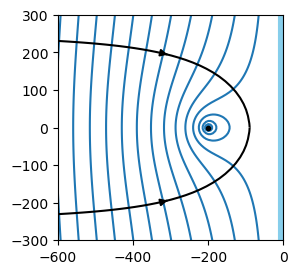

In [7]:
xs = -np.sqrt(xw ** 2 + Q * xw / (np.pi * U))
plt.subplot(121, aspect=1)
plt.contour(xg, yg, h, np.arange(19, 22, 0.1), colors='C0')
for ystart in [0.1, -0.1]:
    plt.streamplot(xg, yg, Qx, Qy, start_points=[(xs, ystart)], 
                   integration_direction='backward', color='k')
plt.plot(xw, yw, 'k.')
plt.axvline(0, color='skyblue', lw=8)
print(f'width of capture zone envelope far upstream: {Q / U:.1f} m')

### Maximum discharge before capturing river water
When the discharge of the well is large, there is no stagnation point between the well and the river. This can be seen from the equation for the stagnation point, as the term under the square root sign becomes negative (recall that $x_w$ is negative). The maximum discharge of the well such that it extracts no river water is when the stagnation point is exactly on the river and $x_s=0$. This gives for the maximum discharge 
\begin{equation}
Q_\text{max}=-\pi U x_w
\end{equation}
The maximum discharge is computed below and the capture zone envelope is plotted. Note that the capture zone envelope touches the river. 

In [8]:
Qmax = -np.pi * U * xw
print(f'maximum discharge: {Qmax:.1f} m^3/d')

maximum discharge: 251.3 m^3/d


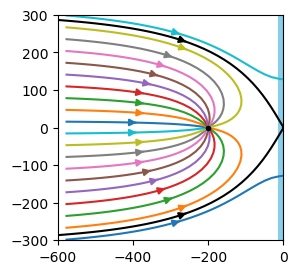

In [9]:
# compute grid of Qx, Qy
xg, yg = np.meshgrid(np.linspace(-600, 0, 100), np.linspace(-300, 300, 100))
Qx, Qy = QxQy(xg, yg, xw, yw, Qmax, U)
# plot streamlines
plt.subplot(121, aspect=1)
plt.axvline(0, color='skyblue', lw=8) # river
xstart = -600 * np.ones(20)
ystart = np.linspace(-300, 300, 20)
for i in range(20):
    plt.streamplot(xg, yg, Qx, Qy, start_points=[(xstart[i], ystart[i])], 
                   integration_direction='forward')
# capture zone envelope
for y in [-0.1, 0.1]:
    plt.streamplot(xg, yg, Qx, Qy, start_points=[(0, y)], 
                   integration_direction='backward', color='k')
plt.plot(xw, yw, 'k.');

### Exercise 1
Consider a well located in a uniform flow field near a river running North-South, as in the previous example. Near the well is a contaminated area as shown in the figure below (run the code cell). For the current discharge of the well ($Q=200$ m$^3$/d), the well captures water from the contaminated area, as can be seen by starting a streampath from the corner of the contaminated area. The discharge of the well must be decreased such that it doesn't capture water from the contaminated area. Determine the maximum discharge of the well such that the well doesn't capture water from the contaminated area.

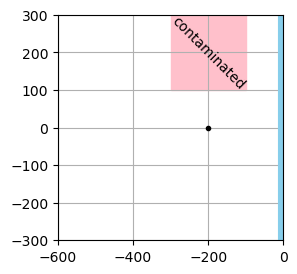

In [10]:
# run this code cell to see the contaminated area
Q = 200
Qx, Qy = QxQy(xg, yg, xw, yw, Q, U)
plt.subplot(121, aspect=1)
plt.plot(xw, yw, 'k.')
plt.axvline(0, color='skyblue', lw=8)
plt.fill([-300, -100, -100, -300], [100, 100, 300, 300], color='pink')
plt.text(-200, 200, 'contaminated', ha='center', va='center', rotation=-45)
plt.xlim(-600, 0)
plt.ylim(-300, 300)
plt.grid()

**Method.**  A point $(x_0, y_0)$ with $y_0 > y_w$ lies exactly on the upper capture-zone boundary when its stream function equals $+Q/2$:
$$\psi(x_0,y_0) = \underbrace{\frac{1}{2\pi}\!\left[\arctan\!\frac{y_0-y_w}{x_0+x_w} - \arctan\!\frac{y_0-y_w}{x_0-x_w}\right]}_{C_1}\cdot Q + \underbrace{U\,y_0}_{C_2} = \frac{Q}{2}$$

Because $C_1$ and $C_2$ do not depend on $Q$, we solve directly:
$$Q_\text{crit} = \frac{C_2}{\tfrac{1}{2} - C_1}$$

The maximum permissible well discharge is the **minimum** $Q_\text{crit}$ over all four corners of the contaminated area.

In [11]:
# --- Exercise 1: find maximum Q that avoids capturing the contaminated area ---
corners = [(-300, 100), (-100, 100), (-100, 300), (-300, 300)]

print('Critical discharge Q_crit for each corner:')
Q_crits = []
for cx, cy in corners:
    C1 = (1 / (2 * np.pi)) * (
        np.arctan2(cy - yw, cx + xw) - np.arctan2(cy - yw, cx - xw))
    C2 = U * cy
    Q_crit = C2 / (0.5 - C1)
    Q_crits.append(Q_crit)
    print(f'  corner ({cx:4d}, {cy:3d}):  C1 = {C1:.4f},  C2 = {C2:.2f},  Q_crit = {Q_crit:.1f} m^3/d')

Q1 = min(Q_crits)
critical_corner = corners[np.argmin(Q_crits)]
print(f'\n>>> Critical corner : {critical_corner}')
print(f'>>> Maximum Q (Ex.1): Q = {Q1:.1f} m^3/d')
print(f'    Above this discharge the well begins to capture the contaminated area.')

Critical discharge Q_crit for each corner:
  corner (-300, 100):  C1 = 0.0936,  C2 = 40.00,  Q_crit = 98.4 m^3/d
  corner (-100, 100):  C1 = 0.3238,  C2 = 40.00,  Q_crit = 227.0 m^3/d
  corner (-100, 300):  C1 = 0.1762,  C2 = 120.00,  Q_crit = 370.6 m^3/d
  corner (-300, 300):  C1 = 0.1128,  C2 = 120.00,  Q_crit = 309.9 m^3/d

>>> Critical corner : (-300, 100)
>>> Maximum Q (Ex.1): Q = 98.4 m^3/d
    Above this discharge the well begins to capture the contaminated area.


Stagnation point at Q = 98.4 m^3/d:  x_s = -156.0 m


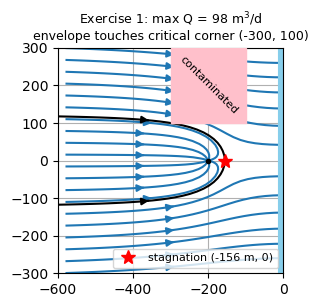

In [12]:
# --- Exercise 1: plot --- 
xg, yg = np.meshgrid(np.linspace(-600, 0, 100), np.linspace(-300, 300, 100))
Qx, Qy = QxQy(xg, yg, xw, yw, Q1, U)

# stagnation point at Q = Q1
xs1 = -np.sqrt(xw ** 2 + Q1 * xw / (np.pi * U))
print(f'Stagnation point at Q = {Q1:.1f} m^3/d:  x_s = {xs1:.1f} m')

plt.subplot(121, aspect=1)
# 20 background streamlines from x = -600
xstart = -600 * np.ones(20)
ystart = np.linspace(-300, 300, 20)
for i in range(20):
    plt.streamplot(xg, yg, Qx, Qy, start_points=[(xstart[i], ystart[i])],
                   integration_direction='forward', color='C0')
# capture-zone envelope: backward from stagnation point
for ystart_env in [0.1, -0.1]:
    plt.streamplot(xg, yg, Qx, Qy, start_points=[(xs1, ystart_env)],
                   integration_direction='backward', color='k')
# contaminated area
plt.fill([-300, -100, -100, -300], [100, 100, 300, 300], color='pink', zorder=3)
plt.text(-200, 200, 'contaminated', ha='center', va='center', rotation=-45, fontsize=8)
plt.plot(xs1, yw, 'r*', ms=10, zorder=5, label=f'stagnation ({xs1:.0f} m, 0)')
plt.plot(xw, yw, 'k.')
plt.axvline(0, color='skyblue', lw=8)
plt.xlim(-600, 0)
plt.ylim(-300, 300)
plt.title(f'Exercise 1: max Q = {Q1:.0f} m$^3$/d\n'
          f'envelope touches critical corner {critical_corner}', fontsize=9)
plt.legend(loc='lower right', fontsize=8)
plt.grid()

### Maximum discharge before capturing river water
When the discharge of the well is large, there is no stagnation point between the well and the river. This can be seen from the equation for the stagnation point, as the term under the square root sign becomes negative (recall that $x_w$ is negative). The maximum discharge of the well such that it extracts no river water is when the stagnation point is exactly on the river and $x_s=0$. This gives for the maximum discharge 
\begin{equation}
Q_\text{max}=-\pi U x_w
\end{equation}

In [13]:
Qmax = -np.pi * U * xw
print(f'maximum discharge before drawing river water: {Qmax:.1f} m^3/d')

maximum discharge before drawing river water: 251.3 m^3/d


### Exercise 2
Create a streamline plot for the case that the well discharge is $Q=300$ m$^3$/d. Start 20 streamlines at $x=-600$ m for $y$ varying from -300 to +300 m (as in the previous example). Next, add 20 streamlines that start at the river at $x=0$ and $y$ varying from -300 to +300 m. Some of the streamlines that start at the river will flow towards the well. 

Q = 300 m^3/d > Qmax = 251.3 m^3/d  =>  well draws river water


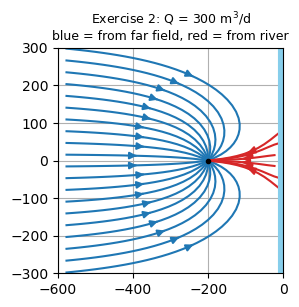

In [14]:
# --- Exercise 2: Q = 300 m^3/d ---
Q = 300
xg, yg = np.meshgrid(np.linspace(-600, 0, 100), np.linspace(-300, 300, 100))
Qx, Qy = QxQy(xg, yg, xw, yw, Q, U)
print(f'Q = {Q} m^3/d > Qmax = {Qmax:.1f} m^3/d  =>  well draws river water')

plt.subplot(121, aspect=1)
# 20 streamlines from x = -600 m (far field, blue)
xstart = -600 * np.ones(20)
ystart = np.linspace(-300, 300, 20)
for i in range(20):
    plt.streamplot(xg, yg, Qx, Qy, start_points=[(xstart[i], ystart[i])],
                   integration_direction='forward', color='C0')
# 20 streamlines from the river x = 0 (start at x = -1 to stay inside grid)
xstart_river = -1 * np.ones(20)
ystart_river = np.linspace(-300, 300, 20)
for i in range(20):
    plt.streamplot(xg, yg, Qx, Qy, start_points=[(xstart_river[i], ystart_river[i])],
                   integration_direction='forward', color='C3')
plt.plot(xw, yw, 'k.')
plt.axvline(0, color='skyblue', lw=8)
plt.xlim(-600, 0)
plt.ylim(-300, 300)
plt.title(f'Exercise 2: Q = {Q} m$^3$/d\n'
          f'blue = from far field, red = from river', fontsize=9)
plt.grid()

### Capture zone when $Q>Q_\text{max}$
When the discharge of the well is larger than $Q_\text{max}$, there are two stagnation points on the river. Between the stagnation points, water from the river flows towards the well. The locations of the stagnation points may be computed from:
\begin{equation}
y_s = y_w \pm \sqrt{\frac{-Qx_w}{\pi U} - x_w^2}
\end{equation}

### Exercise 3
Add the capture zone envelope to the streamline plot of Exercise 2.

Stagnation points on river:  y_s = +88.0 m  and  y_s = -88.0 m


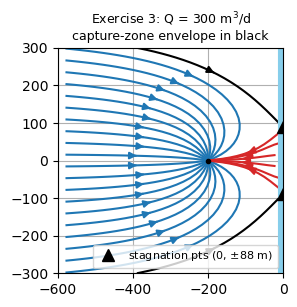

In [15]:
# --- Exercise 3: capture-zone envelope for Q = 300 m^3/d ---
Q = 300
xg, yg = np.meshgrid(np.linspace(-600, 0, 100), np.linspace(-300, 300, 100))
Qx, Qy = QxQy(xg, yg, xw, yw, Q, U)

# two stagnation points on the river (x = 0)
ys_pos = yw + np.sqrt(-Q * xw / (np.pi * U) - xw ** 2)
ys_neg = yw - np.sqrt(-Q * xw / (np.pi * U) - xw ** 2)
print(f'Stagnation points on river:  y_s = +{ys_pos:.1f} m  and  y_s = {ys_neg:.1f} m')

plt.subplot(121, aspect=1)
# 20 streamlines from x = -600 m (far field, blue)
xstart = -600 * np.ones(20)
ystart = np.linspace(-300, 300, 20)
for i in range(20):
    plt.streamplot(xg, yg, Qx, Qy, start_points=[(xstart[i], ystart[i])],
                   integration_direction='forward', color='C0')
# 20 streamlines from the river (red)
xstart_river = -1 * np.ones(20)
ystart_river = np.linspace(-300, 300, 20)
for i in range(20):
    plt.streamplot(xg, yg, Qx, Qy, start_points=[(xstart_river[i], ystart_river[i])],
                   integration_direction='forward', color='C3')
# capture-zone envelope: backward from each stagnation point on the river
for ys_stag in [ys_pos, ys_neg]:
    plt.streamplot(xg, yg, Qx, Qy, start_points=[(-1, ys_stag)],
                   integration_direction='backward', color='k')
# mark the stagnation points
plt.plot([0, 0], [ys_pos, ys_neg], 'k^', ms=8, zorder=5,
         label=f'stagnation pts (0, $\pm${ys_pos:.0f} m)')
plt.plot(xw, yw, 'k.')
plt.axvline(0, color='skyblue', lw=8)
plt.xlim(-600, 0)
plt.ylim(-300, 300)
plt.title(f'Exercise 3: Q = {Q} m$^3$/d\n'
          f'capture-zone envelope in black', fontsize=9)
plt.legend(loc='lower right', fontsize=8)
plt.grid()

---
## Summary of Answers

| Exercise | Key result |
|----------|------------|
| **1** | Maximum Q = **98.4 m³/d** (critical corner: (−300, 100)) |
| **2** | At Q = 300 m³/d > Q_max = 251.3 m³/d the well draws river water |
| **3** | Stagnation points on river at **y = ±88.0 m**; envelope traced backward from those points |

Find more analytic solutions and their application in Python in [Bakker and Post, 2022, Analytical Groundwater Modeling](https://www.routledge.com/Analytical-Groundwater-Modeling-Theory-and-Applications-using-Python/Bakker-Post/p/book/9781138029392). 